In [ ]:
import numpy as np
import pandas as pd
JPM_df= pd.read_csv('JPM.csv')
JPM_df
JPM_df.info()
JPM_df.rename(columns={'Close/Last': 'Adj Close'}, inplace=True)
JPM_df
type(JPM_df)
JPM_df
JPM_df['Daily Returns'] = JPM_df['Adj Close'].pct_change(1)*100
JPM_df['Daily Returns'].replace(np.nan, 0, inplace = True)
JPM_df.describe
import seaborn
import plotly_express as px

def plot_financial_data(df, title):
    fig = px.line(title = title)
    for i in df.columns[1:]:
        fig.add_scatter(x = df['Date'], y = df[i], name = i)
        fig.update_traces(line_width = 5)
        fig.update_layout({'plot_bgcolor': "white"})

    fig.show()




In [24]:
plot_financial_data(JPM_df.drop(['Volume', 'Daily Returns'], axis = 1), 'JP Morgan Chase Stock Price [$]')

In [26]:
plot_financial_data(JPM_df.iloc[:,[0,5]], 'JPM Trading Volume')

In [27]:
def percentage_return_classifier(percentage_return):
    
    if percentage_return > -0.3 and percentage_return <= 0.3:
        return 'Insignificant Change'
    elif percentage_return > 0.3 and percentage_return <= 3:
        return 'Positive Change'
    elif percentage_return > -3 and percentage_return <= -0.3:
        return 'Negative Change'
    elif percentage_return > 3 and percentage_return <= 7:
        return 'Large Positive Change'
    elif percentage_return > -7 and percentage_return <= -3:
        return 'Large Negative Change'
    elif percentage_return > 7:
        return 'Bull Run'
    elif percentage_return <= -7:
        return 'Bear Sell Off'

In [30]:
JPM_df['Trend'] = JPM_df['Daily Returns'].apply(percentage_return_classifier)
JPM_df

,Date,Adj Close,Volume,Open,High,Low,Daily Returns,Trend
0,09/27/2024,210.50,7032450,210.65,212.44,209.33,0.000000,Insignificant Change
1,09/26/2024,209.78,7807480,211.13,211.70,209.01,-0.342043,Negative Change
2,09/25/2024,210.19,8976520,211.68,212.24,208.61,0.195443,Insignificant Change
3,09/24/2024,211.59,7323239,211.15,212.95,210.37,0.666064,Positive Change
4,09/23/2024,211.44,7223491,211.00,211.80,209.99,-0.070892,Insignificant Change
...,...,...,...,...,...,...,...,...
2511,10-06-14,60.18,11576480,60.78,60.80,60.00,1.535347,Positive Change
2512,10-03-14,60.30,18304340,59.25,60.39,59.05,0.199402,Insignificant Change
2513,10-02-14,58.84,24550630,59.15,59.49,58.61,-2.421227,Negative Change
2514,10-01-14,59.77,18995810,60.24,60.40,59.73,1.580557,Positive Change


In [34]:
trend_summary = JPM_df['Trend'].value_counts()
trend_summary

Trend
Negative Change          966
Positive Change          858
Insignificant Change     538
Large Positive Change     78
Large Negative Change     61
Bear Sell Off              8
Bull Run                   7
Name: count, dtype: int64

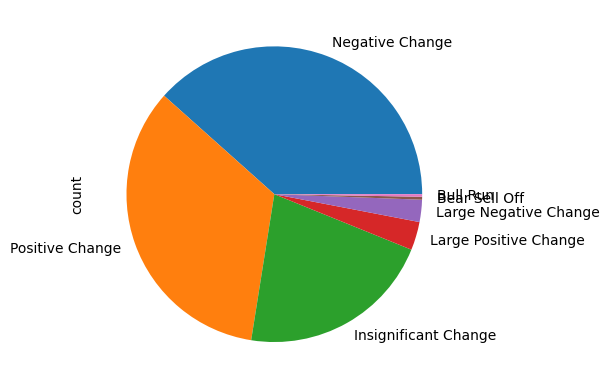

In [35]:
trend_summary.plot(kind = 'pie', y = 'Trend');

In [ ]:
figure = cf.QuantFig(stock_df, title = 'Amazon.com, Inc. (AMZN) Candlestick Chart', name = 'AMZN')
figure.add_sma(periods =[14, 21], column = 'Close', color = ['magenta', 'green'])
figure.iplot(theme = 'white', up_color = 'green', down_color = 'red')